## Use Case: Wildfires

In [7]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time
import tensorflow as tf
from tensorflow.keras.utils import plot_model

from IPython import display

### Load and prepare the dataset

In [2]:
import cv2
import numpy as np

directory_path = 'C:/Users/hadis/OneDrive/Desktop/Projects/GenAI/fire/'

images = []

for filename in os.listdir(directory_path):
    if filename.endswith('.jpg') or filename.endswith('.png'):
        image = cv2.imread(os.path.join(directory_path, filename), cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (128, 128))

        images.append(image)

images = np.array(images)

images = np.expand_dims(images, axis=-1)

In [3]:
print(len(images))
print(len(images[0]))

928
128


In [4]:
train_images = images.reshape(images.shape[0], 128, 128, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

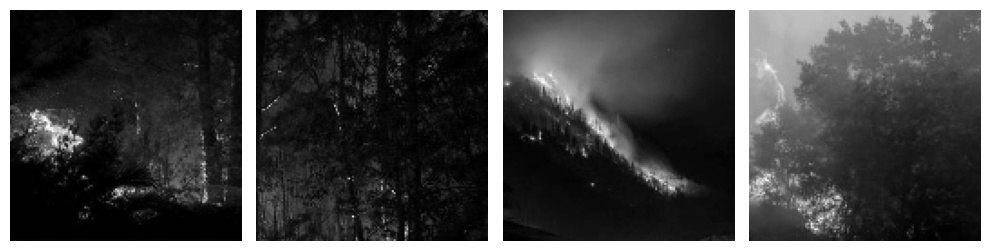

In [6]:
sample_images = train_images[:4]

plt.figure(figsize=(10, 5))

for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(sample_images[i], cmap="gray")
    plt.axis('off')

plt.tight_layout()
plt.show()

The desired image dimension in this case is (128 x 128 x 1), with 1 representing grayscale images. I also tried to use the colored images but the generated outputs didn't match the expected color schema and it took more time to train per epoch.

In [23]:
BUFFER_SIZE = 928
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

The buffer size has to be equal or larger than the original dataset's size as it acts as a container that is randomly filled by the data present in the original dataset, this step is just for shuffling the data.

## Create the models

### The Generator

To generate the model, we first start with a dense layer to act as a bridge between the input noise vector and the higher-dimensional space required by the architecture and extract features that help with generating diverse and realistic samples.
The following layers are deconvolutional to upscale the generated image from (8 x 8) to (128 x 128) with an assertion after each to check if the output matches the expected output. 
LeakyReLU is used as an activation function instead of the regular ReLU as advised in the original paper as it allows for some negative values to pass instead of nullifying all of them.

In [8]:
def make_generator_model():
    model = tf.keras.Sequential()

    model.add(layers.Dense(8 * 8 * 256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8, 8, 256)))
    assert model.output_shape == (None, 8, 8, 256)  

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 16, 16, 128) 

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 32, 32, 64)

    model.add(layers.Conv2DTranspose(32, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 64, 64, 32)  

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 128, 128, 1)  

    return model

generator = make_generator_model()

generator.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16384)             1638400   
                                                                 
 batch_normalization (BatchN  (None, 16384)            65536     
 ormalization)                                                   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 16384)             0         
                                                                 
 reshape (Reshape)           (None, 8, 8, 256)         0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 16, 16, 128)      819200    
 nspose)                                                         
                                                                 
 batch_normalization_1 (Batc  (None, 16, 16, 128)      5

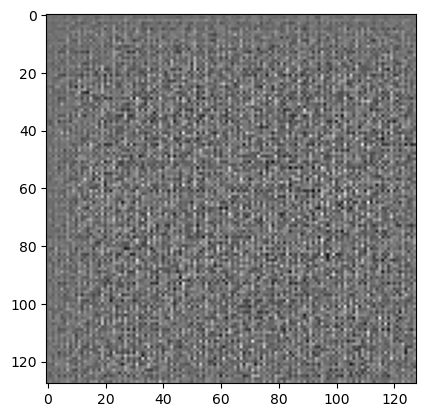

In [10]:
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

### The Discriminator

The discriminator model has a simple 2-layer CNN architecture with the same LeakyReLU activation function and a dense layer with 1 neuron that outputs the probability.

In [28]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[128, 128, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

## Define the loss and optimizers

In [30]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [31]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [32]:
#Optional if we want to save the checkpoints

checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                  discriminator_optimizer=discriminator_optimizer,
                                  generator=generator,
                                  discriminator=discriminator)

## Define the training loop


In [43]:
EPOCHS = 200
noise_dim = 100
num_examples_to_generate = 4

#seed = tf.random.normal([num_examples_to_generate, noise_dim])

*@tf.function* allows for compiling the defined function into a TensorFlow function. The training step starts with a random noise retrieved from the normal distribution. The gradient is used to have a direct access to the gradients in the training step if we're defining a custom training loop. The **training = True** parameter indicates that the model is training, as when we are generating an image later on just to visualize it, the parameter is set to **False** so that it doesn't affect the trained model.
<br>We are then using the gradients while monitoring the loss of each model to tweak the *trainable_variables* of both models.
<br>In each step of the training, we train the models on all batches of the image dataset.

In [39]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [40]:
def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      train_step(image_batch)

    #Optional Steps: 
    display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epoch + 1)

    # Save the model every 15 epochs
    #if (epoch + 1) % 15 == 0:
    #  checkpoint.save(file_prefix = checkpoint_prefix)

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

  # Generate after the final epoch
  display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epochs,)

**Generate and save images**


In [41]:
def generate_and_save_images(model, epoch, test_input):
    
  predictions = model(test_input, training=False)

  fig = plt.figure(figsize=(4, 4))

  for i in range(predictions.shape[0]):
      plt.subplot(2, 2, i+1)
      plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
      plt.axis('off')

  plt.show()

## Train the model

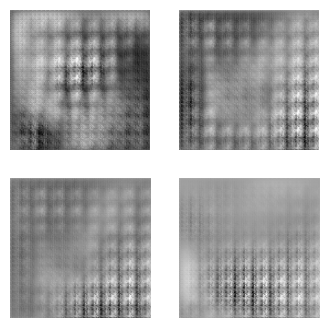

In [44]:
train(train_dataset, EPOCHS)

#### Avg training time approx. 47 secs

<br>As we can see, the images after 200 epochs still contain the *random noise* aspect with repeating patterns but are starting to form with each epoch taking approximately 1 minute to train.

<br>At first, I trained the model with smaller dimensions as put in TensorFlow's architecture: (28 x 28 x 1). The training time was way faster and the generated images after 250 epochs were like a blurred version of the original images, indicating it was on the right course.

<br>What is missing is that I could have added a monitor for the discriminator's accuracy to check if the training follows the graph of *properly trained GAN model* present in the word document report.